# 6.6  Neural Network in Scientific Models (Nonlinear)

In [1]:
using NonlinearSolve
using CairoMakie
using Random
using Distributions
using Lux
using ComponentArrays

using Optimization
using Optimisers
using OptimizationOptimisers
using ForwardDiff

In this notebook we will try to find the heating model  from a cylindrical plate.  We first looked at this problem in Notebook 5.3.  


![Alt text for screen readers](../figures/06p06NonlinearBVP.png)

Here we will see how we can use a Neural Network to find out how the cylindrical plate is heated.  We will use the same strategy as in the previous notebook.  We will first solve the governing equation get the data, $T_i$.   Then given the data, we will replace the heating function with a Neural network to see if we can tune the coefficients of the Neural network to fit the data. WARNING:  The code in this notebook is computationally expensive.  This notebook will take much longer to run than the other notebooks in this course. 


The governing equation for the temperature distribution is given by

$\frac{d^2 T}{dr^2} + \frac{1}{r}\frac{d T}{dr} = d(T^4 - T_R^4) - g(r)$

You are given that $r\in[0,5]$, $d=0.1$, $T_R=10$ and $g(r)=(r-5)^2$.

Again you use the finite diference approximation

$\frac{d^2T}{dr^2}\approx\frac{T_{i-1}-2T_i+T_{i+1}}{\Delta^2}$ 

$\frac{dT}{dr}\approx\frac{T_{i+1}-T_{i-1}}{2\Delta}$ 

We substitute back into the original equation to get

$\frac{T_{i-1}-2T_i+T_{i+1}}{\Delta^2}+\frac{1}{r_i}\frac{T_{i+1}-T_{i-1}}{2\Delta}=d(T_i^4 - T_R^4) - g(r_i)$

This equation is nonlinear (due to the $T^4$ term, we cannot put it into matrix form).  For a grid with 6 data points, we have

$(T_2-T_1)/\Delta=0 \rightarrow T_2-T_1=0$

$\frac{T_{1}-2T_2+T_{3}}{\Delta^2}+\frac{1}{r_2}\frac{T_{3}-T_{1}}{2\Delta}=d(T_2^4 - T_R^4) - g(r_2)$

$\frac{T_{2}-2T_3+T_{4}}{\Delta^2}+\frac{1}{r_3}\frac{T_{3}-T_{2}}{2\Delta}=d(T_3^4 - T_R^4) - g(r_3)$

$\frac{T_{3}-2T_4+T_{5}}{\Delta^2}+\frac{1}{r_4}\frac{T_{3}-T_{3}}{2\Delta}=d(T_4^4 - T_R^4) - g(r_4)$

$\frac{T_{4}-2T_5+T_{6}}{\Delta^2}+\frac{1}{r_5}\frac{T_{3}-T_{4}}{2\Delta}=d(T_5^4 - T_R^4) - g(r_5)$

$T_6=10 \rightarrow T_6-10=0$

We will take the same strategy as the previous notebook.  We will first solve the forward model to get our data and then use the data to see if it can help us tune a Neural Network to give us back the heating model.

In [2]:
d=0.2;TR=10;R=5;
Delta=0.1;
r=0:Delta:R;

Set up parameters of the problem

In [3]:
N=length(r); #n is the number gridpoints
T=10*ones(N);
p=(r[2:N-1].-R).^2 # this is the ground truth of the heating model


49-element Vector{Float64}:
 24.010000000000005
 23.04
 22.090000000000003
 21.159999999999997
 20.25
 19.360000000000003
 18.49
 17.64
 16.81
 16.0
  ⋮
  0.81
  0.6400000000000001
  0.48999999999999994
  0.36
  0.25
  0.16000000000000003
  0.09
  0.04000000000000001
  0.010000000000000002

Define the nonlinear vector functions.  In the function below `p()` is the heating model. 

In [4]:
function HeatedDiskExample(T,p)
    func=vcat( T[1]-T[2],
        ((T[3:N]-2*T[2:N-1]+T[1:N-2])/Delta^2.0).+(1/(2*Delta*r[2:N-1]))*(T[3:N].-T[1:N-2]).-d*(T[2:N-1].^4.0.-TR^4).+p,
       T[N]-TR)
    return func
end   

HeatedDiskExample (generic function with 1 method)

In [5]:
HeatedDiskExample(T,p)

51-element Vector{Float64}:
  0.0
 24.010000000000005
 23.04
 22.090000000000003
 21.159999999999997
 20.25
 19.360000000000003
 18.49
 17.64
 16.81
  ⋮
  0.6400000000000001
  0.48999999999999994
  0.36
  0.25
  0.16000000000000003
  0.09
  0.04000000000000001
  0.010000000000000002
  0.0

Use the `NonlinearSolve()` package in Julia code to solve the problem.

In [6]:
T0=10*ones(length(r)) #initial guess
prob = NonlinearProblem(HeatedDiskExample,T0,p)
sol = NonlinearSolve.solve(prob)

retcode: Stalled
u: 51-element Vector{Float64}:
 10.029743069170305
 10.029743069170305
 10.028664132342852
 10.027498921770123
 10.02634700196618
 10.025218382474442
 10.02411408988066
 10.023034249043842
 10.021978893861958
 10.020948048635198
  ⋮
 10.00080142350397
 10.000613963832759
 10.000451490255656
 10.000314006414923
 10.000201515287696
 10.000114018264396
 10.000051506028191
 10.000013868272578
 10.0

Plot the solution

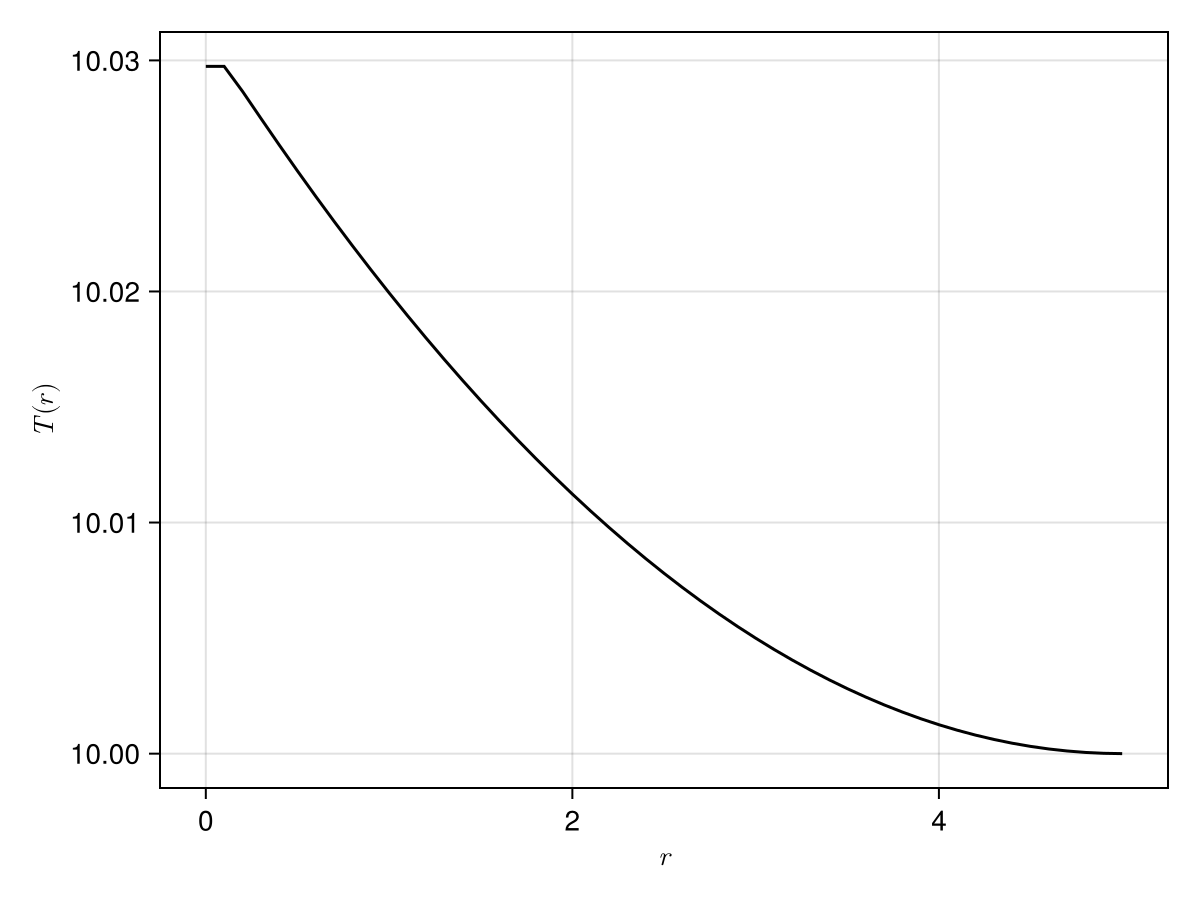

CairoMakie.Screen{IMAGE}


In [7]:
fig = Figure() #set up a figure
ax1 = CairoMakie.Axis(fig[1, 1], xlabel = L"r", ylabel = L"T(r)") #Define axis in the figure
lines!(ax1,r,sol.u;color=:black) #Plot i_5 vs V_1
display(fig)

In [8]:
Tdata=sol.u

51-element Vector{Float64}:
 10.029743069170305
 10.029743069170305
 10.028664132342852
 10.027498921770123
 10.02634700196618
 10.025218382474442
 10.02411408988066
 10.023034249043842
 10.021978893861958
 10.020948048635198
  ⋮
 10.00080142350397
 10.000613963832759
 10.000451490255656
 10.000314006414923
 10.000201515287696
 10.000114018264396
 10.000051506028191
 10.000013868272578
 10.0

So this is our training data

---

Now we will try and see if we can get the heating term $g(r)$ from the data and using a Neural Network to model $g(r)$.  Set up the architecture of the Neural Network

In [9]:
rng=Xoshiro(1) 

gModel = Chain(Dense(1 => 3,tanh),
Dense(3 => 3,tanh),
Dense(3=>1))

# Initialize the model weights and state
parameters, layer_states = Lux.setup(rng, gModel)

((layer_1 = (weight = Float32[-2.4690006; -2.4631705; -2.5724392;;], bias = Float32[-0.94601214, 0.39765334, -0.9980464]), layer_2 = (weight = Float32[1.3124168 -1.023973 -0.3902467; 1.3830966 -1.0305337 0.93506414; 0.5980048 0.90060115 0.9236896], bias = Float32[-0.07401537, -0.38369304, -0.48311597]), layer_3 = (weight = Float32[0.45988524 -0.09438288 0.27005172], bias = Float32[0.031401504])), (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

Set up `loss` for the optimiser

In [10]:
function loss(param,Tdata)   
    T0=10*ones(length(r)) #initial guess 
    gvals,_=gModel(r',param,layer_states)
    p=gvals[2:end-1]
    prob = NonlinearProblem(HeatedDiskExample,T0,p)
    TNN = NonlinearSolve.solve(prob)
    return sum((TNN.-Tdata).^2)
end

loss (generic function with 1 method)

In [11]:
function callback(state, l)
    push!(losses, l)
    if length(losses) % 50 == 0
        println("Current loss after $(length(losses)) iterations: $(losses[end])")
    end
    return false
end

losses = Float64[]
adtype = AutoForwardDiff()
optf = OptimizationFunction(loss, adtype)

#optprob = OptimizationProblem(optf,ComponentArray(sol.u),Float32.(ydata))
optprob = OptimizationProblem(optf,ComponentArray(parameters),Float32.(Tdata))
sol=Optimization.solve(optprob,Adam(0.1f0),maxiters=2000, callback=callback)

Current loss after 50 iterations: 0.004402133170515299
Current loss after 100 iterations: 0.004381922539323568
Current loss after 150 iterations: 0.004381722304970026
Current loss after 200 iterations: 0.004381717648357153
Current loss after 250 iterations: 0.004381714854389429
Current loss after 300 iterations: 0.00438171299174428
Current loss after 350 iterations: 0.004381711129099131
Current loss after 400 iterations: 0.004381709732115269
Current loss after 450 iterations: 0.004381708335131407
Current loss after 500 iterations: 0.004381707403808832
Current loss after 550 iterations: 0.00438170600682497
Current loss after 600 iterations: 0.004381704609841108
Current loss after 650 iterations: 0.004381702747195959
Current loss after 700 iterations: 0.00438170088455081
Current loss after 750 iterations: 0.004381698556244373
Current loss after 800 iterations: 0.004381694830954075
Current loss after 850 iterations: 0.0043816897086799145
Current loss after 900 iterations: 0.00438168039545

retcode: Default
u: ComponentVector{Float32}(layer_1 = (weight = Float32[-0.494464; -0.9707485; -3.4914603;;], bias = Float32[0.629945, 1.5787249, -2.9110053]), layer_2 = (weight = Float32[2.6358047 -0.8795146 -0.3748974; -0.33105648 0.07177882 5.1845593; -1.5579252 1.0068098 3.6773732], bias = Float32[-0.0053861965, -5.8795314, -4.680301]), layer_3 = (weight = Float32[14.529892 -4.32119 -3.9911258], bias = Float32[4.234879]))

Compute the solution with  latest parameters of the Neural Network to see if we have manage to compute the solution. 

In [12]:
T0=ones(length(r)) #initial guess
gvals,_=gModel(r',sol.u,layer_states)
p=gvals[2:end-1]
prob = NonlinearProblem(HeatedDiskExample,T0,p)
TNN = NonlinearSolve.solve(prob)

┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Base.ReshapedArray{Float32, 2, SubArray{Float32, 1, Vector{Float32}, Tuple{UnitRange{Int64}}, true}, Tuple{}}] x B [LinearAlgebra.Adjoint{Float64, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}]). Falling back to generic implementation. This may be slow.
└ @ LuxLib.Impl /Users/asho/.julia/packages/LuxLib/zPBrt/src/impl/matmul.jl:194


retcode: Stalled
u: 51-element Vector{Float64}:
 10.02894680126863
 10.02894680126863
 10.028325192642294
 10.027552583989088
 10.026676061642696
 10.025704937005235
 10.024650500192953
 10.02353029020943
 10.022367748779564
 10.021190290085503
  ⋮
 10.001004544425497
 10.000863814498612
 10.000738522624449
 10.000626897382151
 10.00052735303614
 10.000438334845184
 10.000356952832155
 10.000265624116372
 10.0

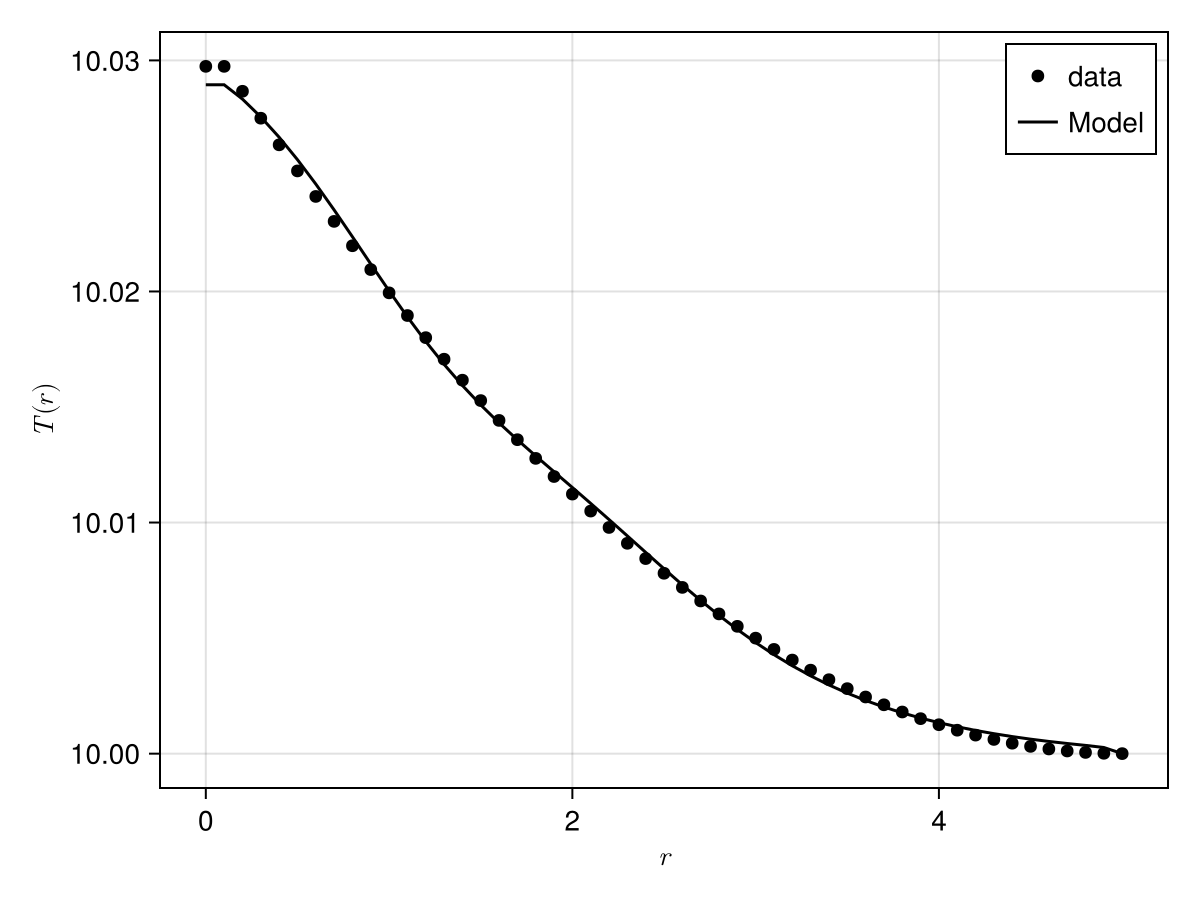

In [13]:
fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"r", ylabel = L"T(r)")
scatter!(ax,r,Tdata,color=:black,label="data")
lines!(ax,r,TNN,color=:black,label="Model")
axislegend(ax,position=:rt)
fig

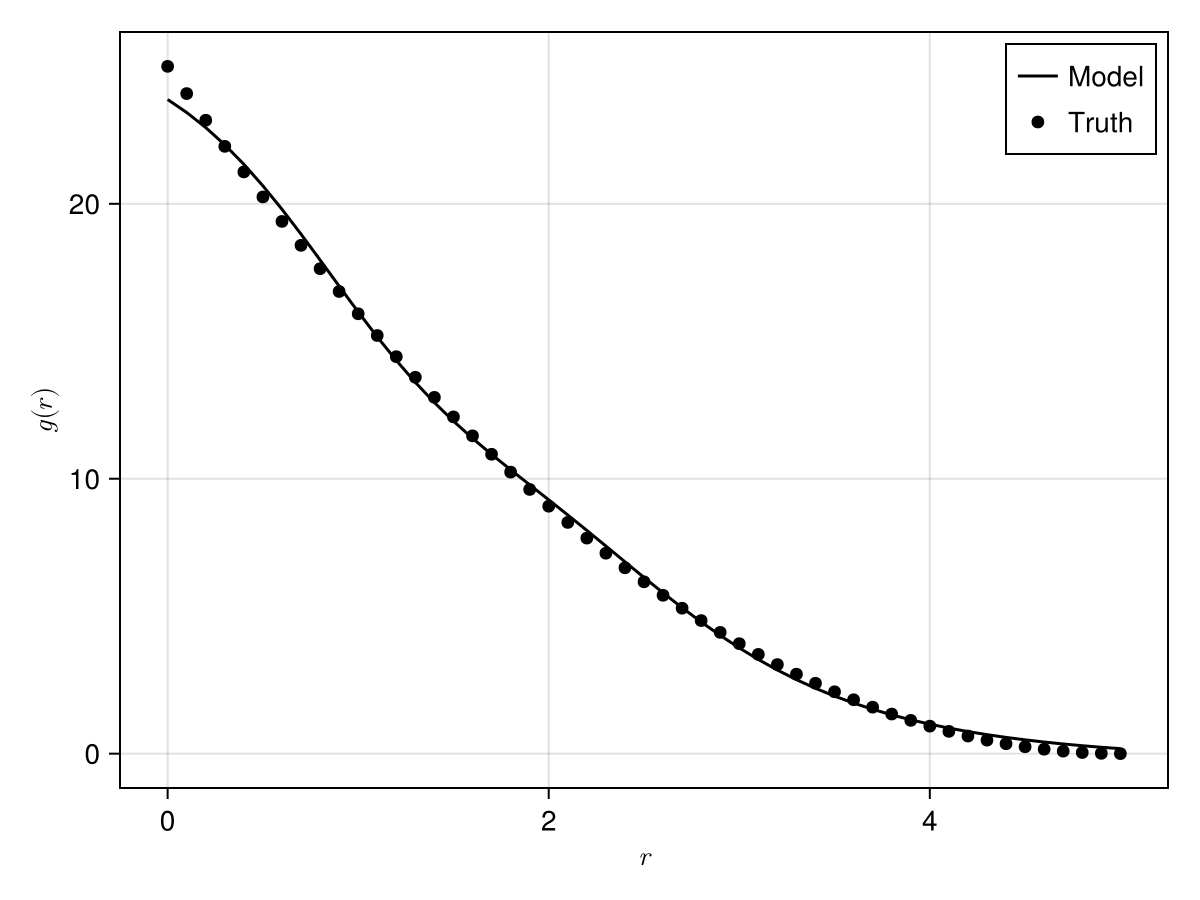

In [14]:
fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"r", ylabel = L"g(r)")
lines!(ax,r,gvals[:],color=:black,label="Model")
scatter!(ax,r,(r.-R).^2,color=:black,label="Truth")
axislegend(ax,position=:rt)
fig

Now that the Neural Network is a good approximation of $g(r)$, we can use it to predict $T(r)$ when other parameters change. 